# Gradient Boosting Regressor

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Training and Validation Data

In [2]:
# Load datasets
df_train = pd.read_csv('gs://aura_datasets_training_validation/AURA_aug_sep_60k.csv')
df_val   = pd.read_csv('gs://aura_datasets_training_validation/AURA_validation_sep_12k.csv')

# Feature and target columns
feature_cols = ['noise_db', 'light_lux', 'crowd_count']
target_col   = 'discomfort_level'

X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_val = df_val[feature_cols]
y_val = df_val[target_col]

# Show head of X_train
X_train.head()


,noise_db,light_lux,crowd_count
0,44.6,395,8
1,60.1,689,19
2,69.5,548,13
3,32.0,120,1
4,34.3,120,1


## Preprocess the Features

In [3]:
# Numeric transformer
numeric_features = feature_cols
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)


## Build and Tune the Gradient Boosting Regressor

In [4]:
# Initialize gradient boosting regressor
gb_reg = GradientBoostingRegressor()

# Pipeline
gb_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', gb_reg)
])

# Hyperparameter grid
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 4],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__subsample': [0.8, 1.0]
}

# Grid search (5-fold CV) using negative MAE
gb_grid = GridSearchCV(
    estimator=gb_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

# Fit grid search
gb_grid.fit(X_train, y_train)

print('Best parameters:', gb_grid.best_params_)
print('Best cross-validated MAE:', -gb_grid.best_score_)


Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 10, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Best cross-validated MAE: 0.0033333692135440857


## Evaluate the Gradient Boosting Regressor

Mean Absolute Error: 0.0037
Mean Squared Error: 0.0000
R² Score: 0.9995


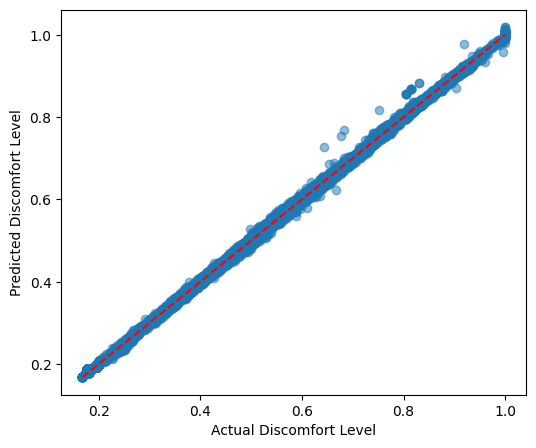

In [7]:
# Best estimator
best_gb = gb_grid.best_estimator_

# Predict on validation set
y_val_pred_gb = best_gb.predict(X_val)

# Metrics
mae = mean_absolute_error(y_val, y_val_pred_gb)
mse = mean_squared_error(y_val, y_val_pred_gb)
r2  = r2_score(y_val, y_val_pred_gb)
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R² Score: {r2:.4f}')

# Plot actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_val, y_val_pred_gb, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Discomfort Level')
plt.ylabel('Predicted Discomfort Level')
plt.show()

## Learning Curve

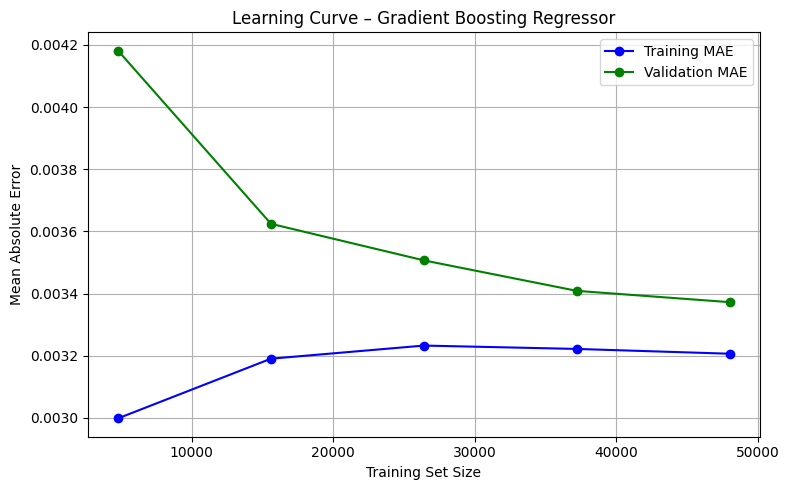

In [10]:
# Compute learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_gb,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    n_jobs=-1
)

# Convert to positive MAE
train_mae = -train_scores
val_mae   = -val_scores

# Compute means and stds
train_mean = train_mae.mean(axis=1)
train_std  = train_mae.std(axis=1)
val_mean   = val_mae.mean(axis=1)
val_std    = val_mae.std(axis=1)

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.title('Learning Curve – Gradient Boosting Regressor')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Absolute Error')

plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training MAE')

plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation MAE')

plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
